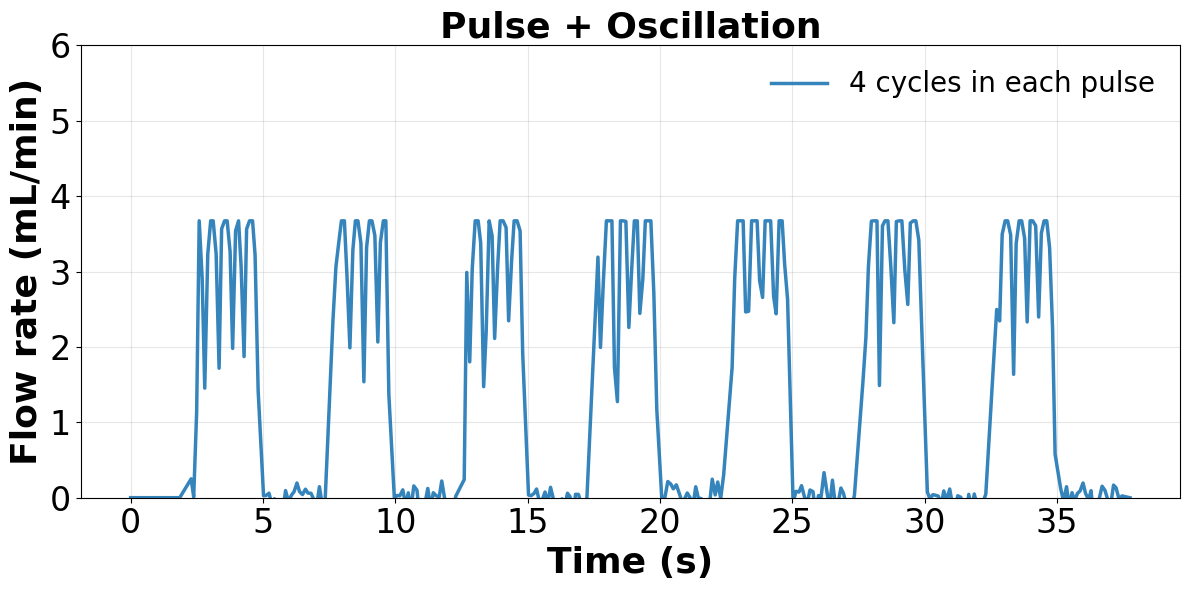

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

edf_path = '/content/oscillation+pulse.edf'
flow_col = 'F_SLF3S_600_2521000029'

df = pd.read_csv(edf_path, comment='#', sep='\t')

df['Local_Date_Time'] = pd.to_datetime(df['Local_Date_Time'])

df['Elapsed_s'] = (
    df['Local_Date_Time'] - df['Local_Date_Time'].iloc[0]
).dt.total_seconds()



array1 = np.array(df['Elapsed_s'])
array2 = np.array(df[flow_col])  # already equals 1.13 * original array2

# -------- Plot --------
plt.figure(figsize=(12,6))

color1 = '#1f77b4'

plt.plot(
    array1,
    array2/1000,   # already scaled → DO NOT multiply again
    color=color1,
    linewidth=2.5,
    alpha=0.9,
    label='4 cycles in each pulse'
)

plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (mL/min)", fontsize=26, fontweight='bold')
plt.title("Pulse + Oscillation", fontsize=26, fontweight='bold')

plt.ylim(0, 6)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.legend(loc='upper right', fontsize=20, frameon=False)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

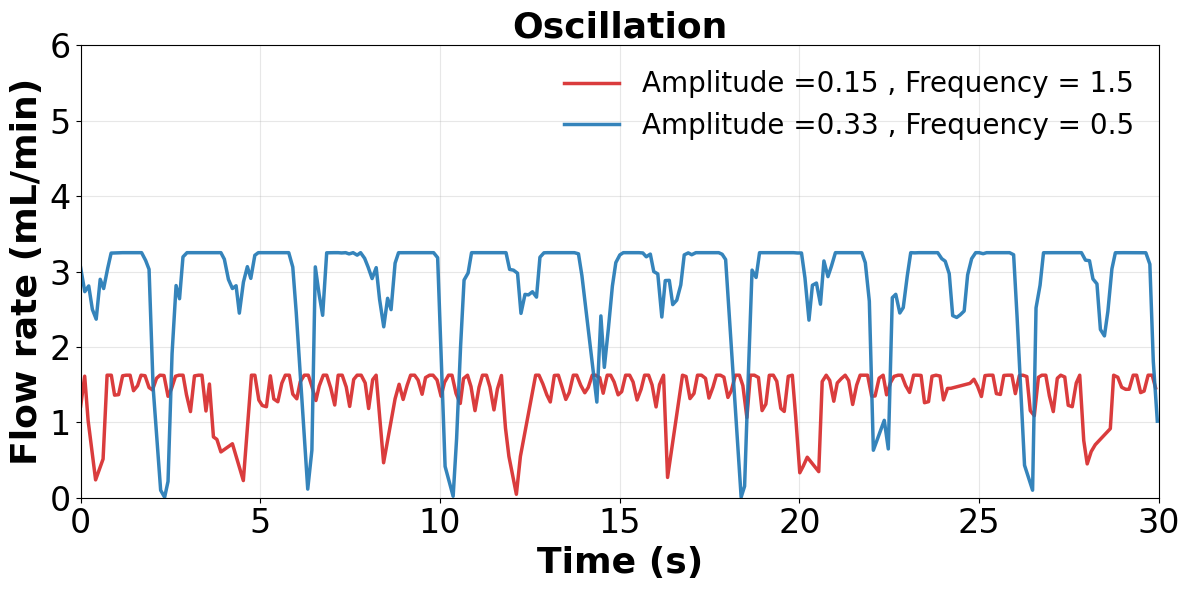

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

flow_col = 'F_SLF3S_600_2521000029'

edf_path1 = '/content/exp1-oscillation.edf'
edf_path2 = '/content/exp2-oscillation.edf'

df1 = pd.read_csv(edf_path1, comment='#', sep='\t')
df2 = pd.read_csv(edf_path2, comment='#', sep='\t')

x1 = np.array(df1['Elapsed_s'], dtype=float)
y1 = np.array(df1[flow_col], dtype=float)

x2 = np.array(df2['Elapsed_s'], dtype=float)
y2 = np.array(df2[flow_col], dtype=float)

xmin, xmax = 0, 30

plt.figure(figsize=(12,6))

# Paper-style colors
color1 = '#d62728'   # muted red
color2 = '#1f77b4'   # deep blue

plt.plot(x1, y1/1000,
         color=color1, linewidth=2.5, alpha=0.9, label='Amplitude =0.15 , Frequency = 1.5')

plt.plot(x2, y2/1000,
         color=color2, linewidth=2.5, alpha=0.9, label='Amplitude =0.33 , Frequency = 0.5')

# Labels and title
plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (mL/min)", fontsize=26, fontweight='bold')
plt.title("Oscillation", fontsize=26, fontweight='bold')

# Axis limits
plt.ylim(0, 6)
plt.xlim(xmin, xmax)

# Tick size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Legend
plt.legend(loc='upper right', fontsize=20, frameon=False)

# Light grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

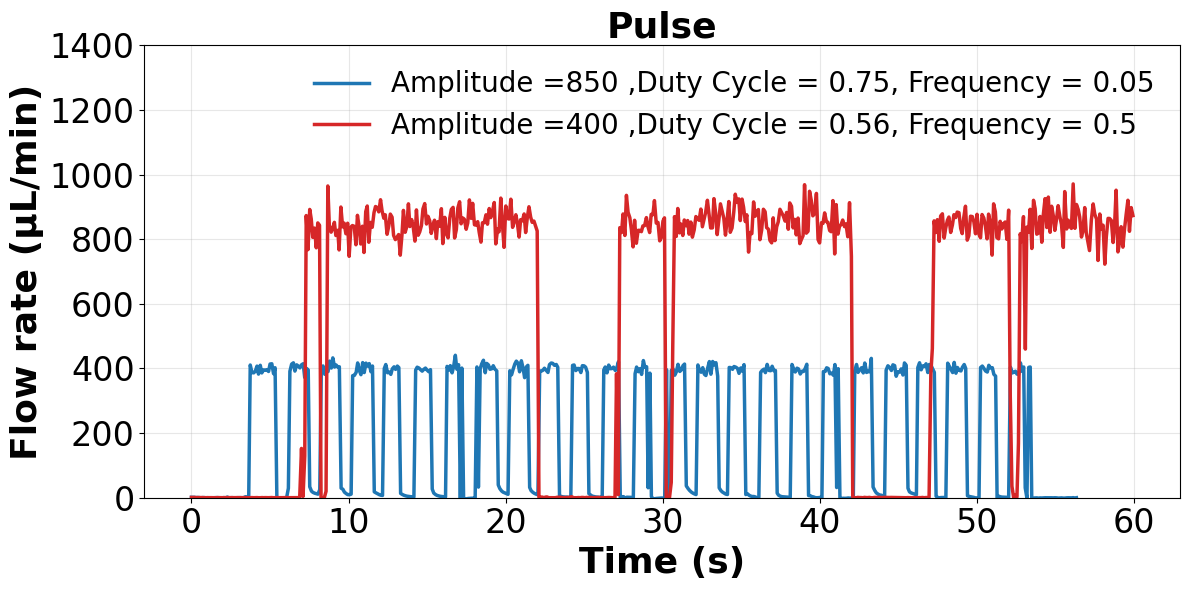

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

file1 = '/content/pulse1.edf'
file2 = '/content/pulse2.edf'

# -------- Load data --------
df1 = pd.read_csv(file1, comment='#', sep='\t')
df1['Local_Date_Time'] = pd.to_datetime(df1['Local_Date_Time'], format='mixed')
df1['Elapsed_s'] = (df1['Local_Date_Time'] - df1['Local_Date_Time'].iloc[0]).dt.total_seconds()

df2 = pd.read_csv(file2, comment='#', sep='\t')
df2['Local_Date_Time'] = pd.to_datetime(df2['Local_Date_Time'])
df2['Elapsed_s'] = (df2['Local_Date_Time'] - df2['Local_Date_Time'].iloc[0]).dt.total_seconds()

# Optional: limit to first 60 seconds
df1 = df1[df1['Elapsed_s'] <= 60]
df2 = df2[df2['Elapsed_s'] <= 60]

# -------- Plot --------
plt.figure(figsize=(12,6))

# Paper-style colors (muted but distinct)
color1 = '#1f77b4'   # deep blue
color2 = '#d62728'   # muted red

plt.plot(df1['Elapsed_s'], df1['F_SLF3S_600_2521000056'],
         label='Amplitude =850 ,Duty Cycle = 0.75, Frequency = 0.05', linewidth=2.5, color=color1)

plt.plot(df2['Elapsed_s'], df2['F_SLF3S_600_2521000056'],
         label='Amplitude =400 ,Duty Cycle = 0.56, Frequency = 0.5', linewidth=2.5, color=color2)

# Labels and title (bold + large)
plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (µL/min)", fontsize=26, fontweight='bold')
plt.title("Pulse", fontsize=26, fontweight='bold')

# Tick size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Legend top right
plt.legend(loc='upper right', fontsize=20, frameon=False)

# Clean grid (light)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1400)
plt.tight_layout()
plt.show()

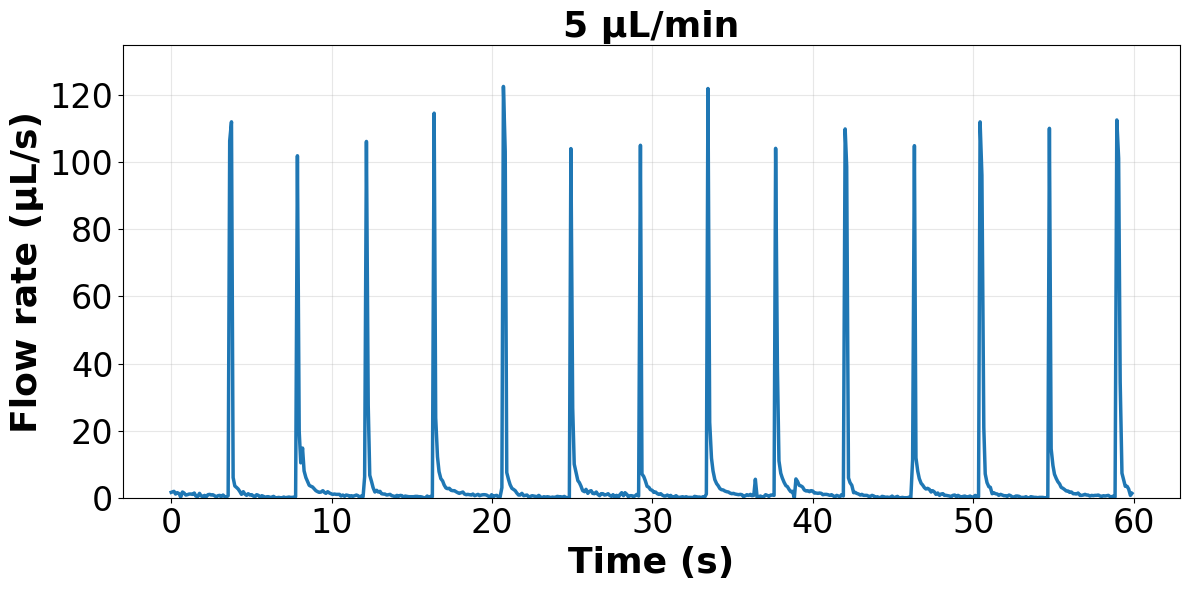

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- Load file 1 --------
df1 = pd.read_csv('/content/50ul-5.edf', comment='#', sep='\t')
df1['Local_Date_Time'] = pd.to_datetime(df1['Local_Date_Time'], format='mixed')
df1['Elapsed_s'] = (df1['Local_Date_Time'] - df1['Local_Date_Time'].iloc[0]).dt.total_seconds()

# -------- Load file 2 --------
df2 = pd.read_csv('/content/50ul-50.edf', comment='#', sep='\t')
df2['Local_Date_Time'] = pd.to_datetime(df2['Local_Date_Time'], format='mixed')
df2['Elapsed_s'] = (df2['Local_Date_Time'] - df2['Local_Date_Time'].iloc[0]).dt.total_seconds()

# Limit to first 60 seconds
df1 = df1[df1['Elapsed_s'] <= 60]
df2 = df2[df2['Elapsed_s'] <= 60]

# -------- Shared y-limit --------
ymax = max(df1['F_SLF3S_600_2521000056'].max(),
           df2['F_SLF3S_600_2521000056'].max())

color1 = '#1f77b4'
color2 = '#d62728'

# -------- Figure 1 --------
plt.figure(figsize=(12,6))

plt.plot(df1['Elapsed_s'],
         df1['F_SLF3S_600_2521000056'],
         color=color1,
         linewidth=2.5)

plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (µL/s)", fontsize=26, fontweight='bold')
plt.title("5 µL/min", fontsize=26, fontweight='bold')

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.ylim(0, ymax * 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




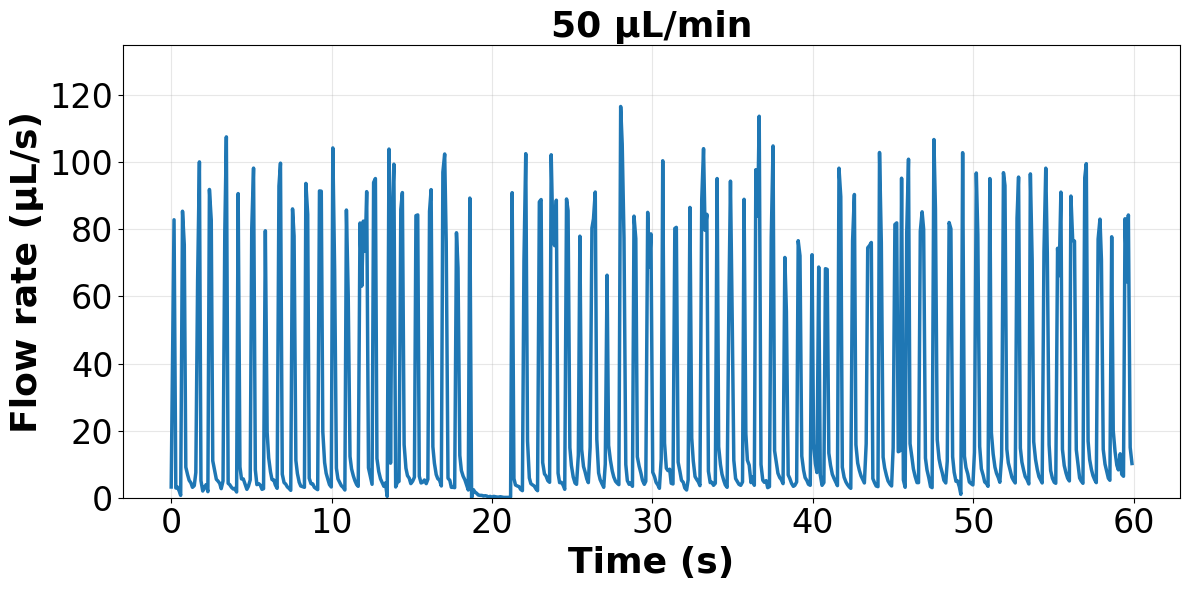

In [7]:
# -------- Figure 2 --------
plt.figure(figsize=(12,6))

plt.plot(df2['Elapsed_s'],
         df2['F_SLF3S_600_2521000056'],
         color=color1,
         linewidth=2.5)

plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (µL/s)", fontsize=26, fontweight='bold')
plt.title("50 µL/min", fontsize=26, fontweight='bold')

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.ylim(0, ymax * 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

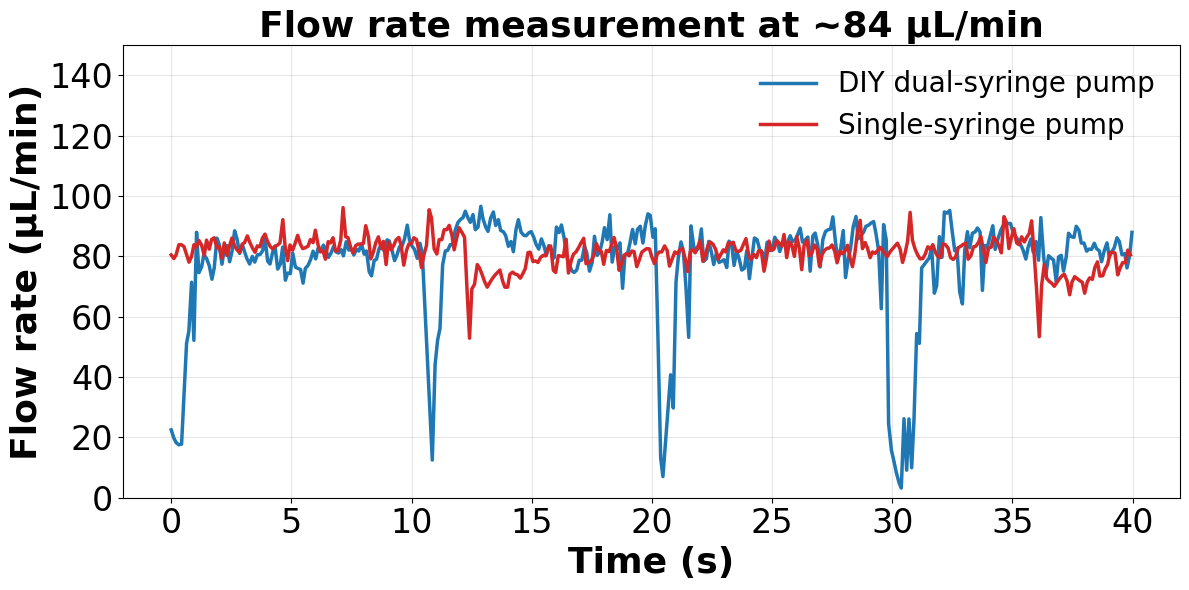

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- Load file 1 --------
df1 = pd.read_csv('/content/DIY-85ul.edf', comment='#', sep='\t')
df1['Local_Date_Time'] = pd.to_datetime(df1['Local_Date_Time'], format='mixed')
df1['Elapsed_s'] = (df1['Local_Date_Time'] - df1['Local_Date_Time'].iloc[0]).dt.total_seconds()

# -------- Load file 2 --------
df2 = pd.read_csv('/content/singlesyringe_85ul.edf', comment='#', sep='\t')
df2['Local_Date_Time'] = pd.to_datetime(df2['Local_Date_Time'], format='mixed')
df2['Elapsed_s'] = (df2['Local_Date_Time'] - df2['Local_Date_Time'].iloc[0]).dt.total_seconds()

# Optional: limit to first 60 seconds
df1 = df1[df1['Elapsed_s'] <= 60]
df2 = df2[df2['Elapsed_s'] <= 60]

# -------- Plot --------
plt.figure(figsize=(12,6))

# Same color scheme as your previous plots
color1 = '#1f77b4'   # blue
color2 = '#d62728'   # red

plt.plot(df1['Elapsed_s'],
         df1['F_SLF3S_600_2521000056'],
         color=color1,
         linewidth=2.5,
         label='DIY dual-syringe pump')

plt.plot(df2['Elapsed_s'],
         df2['F_SLF3S_600_2521000056'],
         color=color2,
         linewidth=2.5,
         label='Single-syringe pump')

# Labels and title (same style)
plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (µL/min)", fontsize=26, fontweight='bold')
plt.title("Flow rate measurement at ~84 µL/min", fontsize=26, fontweight='bold')

# Tick size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Dynamic y-limit
ymax = max(df1['F_SLF3S_600_2521000056'].max(),
           df2['F_SLF3S_600_2521000056'].max())
plt.ylim(0, 150)

# Legend
plt.legend(loc='upper right', fontsize=20, frameon=False)

# Grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

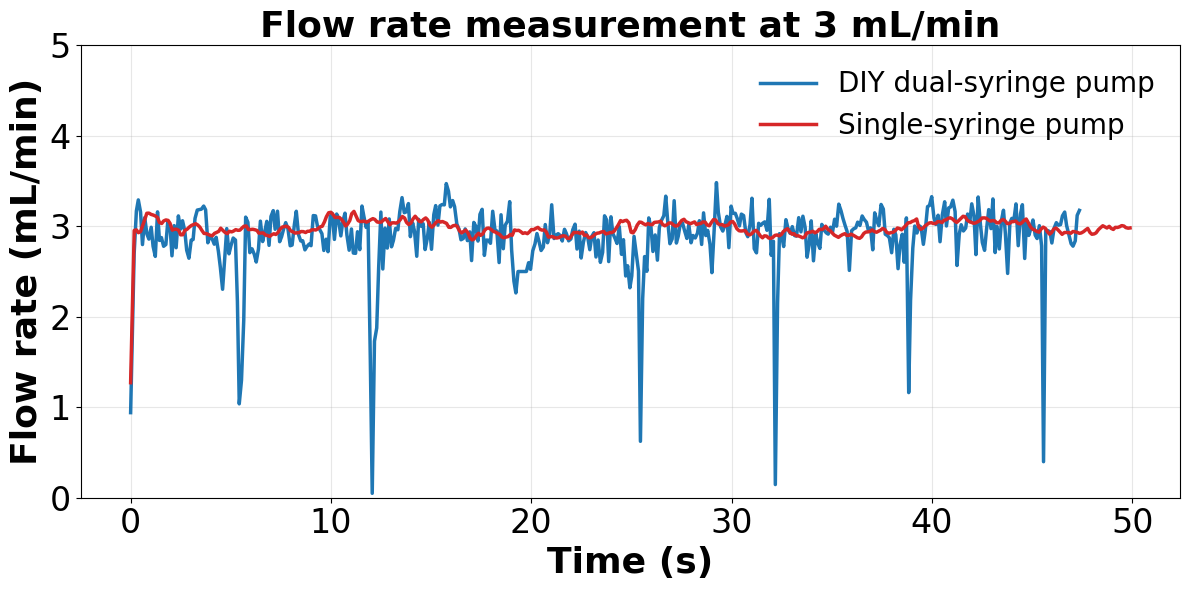

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- Load file 1 --------
df1 = pd.read_csv('/content/DIY_3ml.edf', comment='#', sep='\t')
df1['Local_Date_Time'] = pd.to_datetime(df1['Local_Date_Time'], format='mixed')
df1['Elapsed_s'] = (df1['Local_Date_Time'] - df1['Local_Date_Time'].iloc[0]).dt.total_seconds()

# -------- Load file 2 --------
df2 = pd.read_csv('/content/singlesyringe-3ml.edf', comment='#', sep='\t')
df2['Local_Date_Time'] = pd.to_datetime(df2['Local_Date_Time'], format='mixed')
df2['Elapsed_s'] = (df2['Local_Date_Time'] - df2['Local_Date_Time'].iloc[0]).dt.total_seconds()

# Optional: limit to first 60 seconds
df1 = df1[df1['Elapsed_s'] <= 60]
df2 = df2[df2['Elapsed_s'] <= 60]

# -------- Plot --------
plt.figure(figsize=(12,6))

# Same color scheme as your previous plots
color1 = '#1f77b4'   # blue
color2 = '#d62728'   # red

plt.plot(df1['Elapsed_s'],
         df1['F_SLF3S_600_2521000029'] / 1000,
         color=color1,
         linewidth=2.5,
         label='DIY dual-syringe pump')

plt.plot(df2['Elapsed_s'],
         df2['F_SLF3S_600_2521000056']/ 1000,
         color=color2,
         linewidth=2.5,
         label='Single-syringe pump')

# Labels and title (same style)
plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (mL/min)", fontsize=26, fontweight='bold')
plt.title("Flow rate measurement at 3 mL/min", fontsize=26, fontweight='bold')

# Tick size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Dynamic y-limit (important for consistency)
ymax = max((df1['F_SLF3S_600_2521000029'] / 1000).max(),
           df2['F_SLF3S_600_2521000056'].max())
plt.ylim(0, 5)

# Legend (clean, top-right)
plt.legend(loc='upper right', fontsize=20, frameon=False)

# Grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

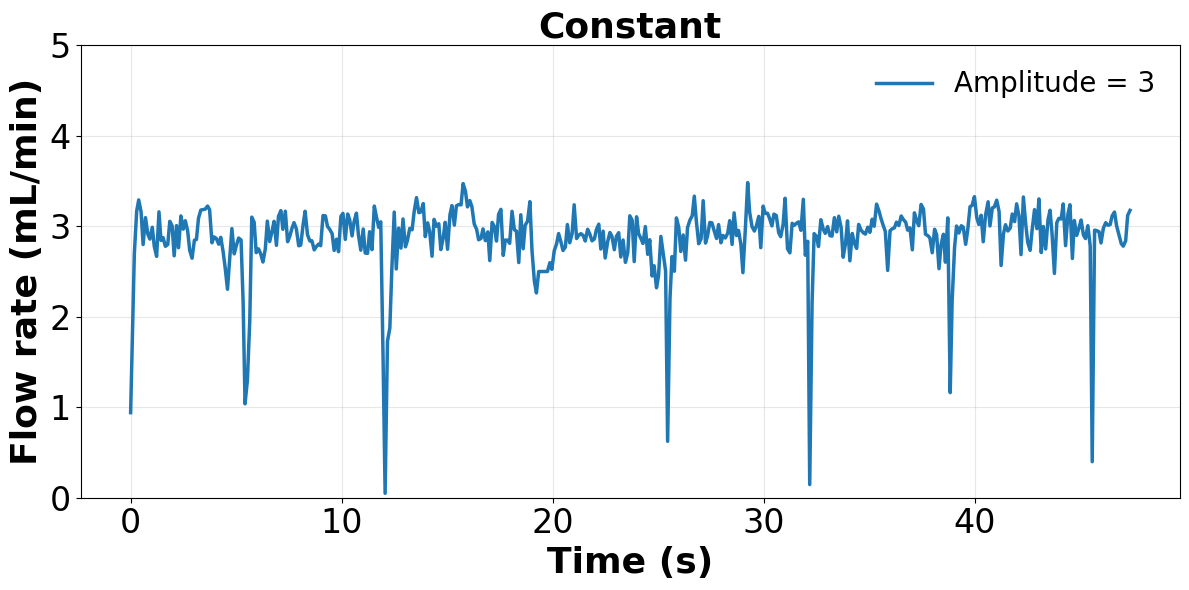

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- Load file 1 --------
df1 = pd.read_csv('/content/DIY_3ml.edf', comment='#', sep='\t')
df1['Local_Date_Time'] = pd.to_datetime(df1['Local_Date_Time'], format='mixed')
df1['Elapsed_s'] = (df1['Local_Date_Time'] - df1['Local_Date_Time'].iloc[0]).dt.total_seconds()

# -------- Load file 2 --------
df2 = pd.read_csv('/content/singlesyringe-3ml.edf', comment='#', sep='\t')
df2['Local_Date_Time'] = pd.to_datetime(df2['Local_Date_Time'], format='mixed')
df2['Elapsed_s'] = (df2['Local_Date_Time'] - df2['Local_Date_Time'].iloc[0]).dt.total_seconds()

# Optional: limit to first 60 seconds
df1 = df1[df1['Elapsed_s'] <= 60]
df2 = df2[df2['Elapsed_s'] <= 60]

# -------- Plot --------
plt.figure(figsize=(12,6))

# Same color scheme as your previous plots
color1 = '#1f77b4'   # blue
color2 = '#d62728'   # red

plt.plot(df1['Elapsed_s'],
         df1['F_SLF3S_600_2521000029'] / 1000,
         color=color1,
         linewidth=2.5,
         label='Amplitude = 3')

# plt.plot(df2['Elapsed_s'],
#          df2['F_SLF3S_600_2521000056']/ 1000,
#          color=color2,
#          linewidth=2.5,
#          label='Single-syringe pump')

# Labels and title (same style)
plt.xlabel("Time (s)", fontsize=26, fontweight='bold')
plt.ylabel("Flow rate (mL/min)", fontsize=26, fontweight='bold')
plt.title("Constant", fontsize=26, fontweight='bold')

# Tick size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Dynamic y-limit (important for consistency)
ymax = max((df1['F_SLF3S_600_2521000029'] / 1000).max(),
           df2['F_SLF3S_600_2521000056'].max())
plt.ylim(0, 5)

# Legend (clean, top-right)
plt.legend(loc='upper right', fontsize=20, frameon=False)

# Grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()